# Credit Card Fraud Detection — Part 1: EDA & Data Preparation
**Kate Pogrebnyakova | Data Scientist**

**Business question:** A bank processes 284,807 credit card transactions over 2 days.
492 are fraudulent — just 0.17% of all transactions.
How do we build a model that catches as much fraud as possible without blocking too many legitimate customers?

**Why this matters:** A model that predicts "no fraud" for every transaction achieves 99.83% accuracy.
That is a useless model. This notebook demonstrates why accuracy is the wrong metric for imbalanced
classification and sets up the data correctly for modelling.

---
## Table of Contents
1. [Setup & Data Loading](#setup)
2. [Class Imbalance](#class-imbalance)
3. [Transaction Amount Analysis](#amount)
4. [Time Distribution](#time)
5. [Feature Distributions](#features)
6. [Correlation Structure](#correlation)
7. [Preprocessing for Modelling](#preprocessing)


## 1. Setup & Data Loading <a id='setup'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
import os

sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize': (11, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

NAVY  = '#1a3a5c'
TEAL  = '#00897b'
CORAL = '#e64a19'
GREY  = '#78909c'

os.makedirs('../outputs/plots', exist_ok=True)

def save(name):
    plt.savefig(f'../outputs/plots/{name}.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()


In [2]:
df = pd.read_csv('../data/raw/creditcard.csv')

print(f"Shape:          {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nClass distribution:")
vc = df['Class'].value_counts()
for cls, cnt in vc.items():
    label = 'Fraud' if cls == 1 else 'Legitimate'
    print(f"  {label} ({cls}): {cnt:>7,}  ({cnt/len(df)*100:.3f}%)")
print(f"\nAmount range: €{df['Amount'].min():.2f} – €{df['Amount'].max():,.2f}")
print(f"Time range:   {df['Time'].min():.0f}s – {df['Time'].max():.0f}s "
      f"({df['Time'].max()/3600:.1f} hours)")
df.describe().round(3)


Shape:          (284807, 31)
Missing values: 0

Class distribution:
  Legitimate (0): 284,315  (99.827%)
  Fraud (1):     492  (0.173%)

Amount range: €0.00 – €25,691.16
Time range:   0s – 172792s (48.0 hours)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,...,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,...,0.000,-0.000,0.000,0.000,0.000,0.000,-0.000,-0.000,88.350,0.002
std,47488.146,1.959,1.651,1.516,1.416,1.380,1.332,1.237,1.194,1.099,...,0.735,0.726,0.624,0.606,0.521,0.482,0.404,0.330,250.120,0.042
min,0.000,-56.408,-72.716,-48.326,-5.683,-113.743,-26.161,-43.557,-73.217,-13.434,...,-34.830,-10.933,-44.808,-2.837,-10.295,-2.605,-22.566,-15.430,0.000,0.000
25%,54201.500,-0.920,-0.599,-0.890,-0.849,-0.692,-0.768,-0.554,-0.209,-0.643,...,-0.228,-0.542,-0.162,-0.355,-0.317,-0.327,-0.071,-0.053,5.600,0.000
50%,84692.000,0.018,0.065,0.180,-0.020,-0.054,-0.274,0.040,0.022,-0.051,...,-0.029,0.007,-0.011,0.041,0.017,-0.052,0.001,0.011,22.000,0.000
75%,139320.500,1.316,0.804,1.027,0.743,0.612,0.399,0.570,0.327,0.597,...,0.186,0.529,0.148,0.440,0.351,0.241,0.091,0.078,77.165,0.000
max,172792.000,2.455,22.058,9.383,16.875,34.802,73.302,120.589,20.007,15.595,...,27.203,10.503,22.528,4.585,7.520,3.517,31.612,33.848,25691.160,1.000


## 2. Class Imbalance <a id='class-imbalance'></a>

The first and most important observation: **492 fraud cases in 284,807 transactions = 0.17%**.

This is extreme class imbalance. It means:
- A naive model predicting "no fraud" for everything scores 99.83% accuracy
- Standard accuracy is a meaningless metric for this problem
- We must use **Precision-Recall AUC** (Average Precision) as our primary metric


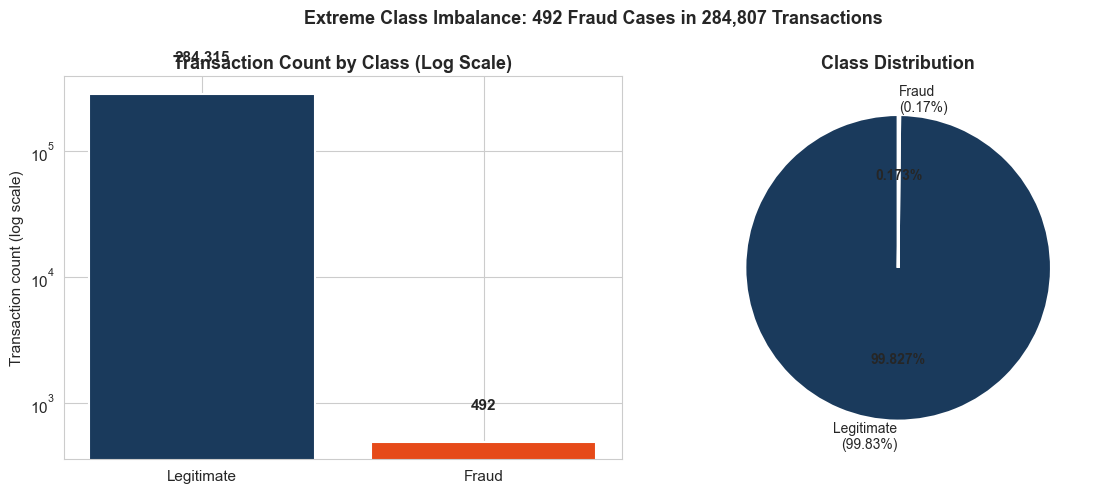


Baseline accuracy (predict all legitimate): 99.83%
This is why accuracy is the WRONG metric for this problem.


In [3]:
counts = df['Class'].value_counts()
fraud_pct = counts[1] / len(df) * 100
legit_pct = counts[0] / len(df) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: log-scale bar to show both classes
bars = axes[0].bar(['Legitimate', 'Fraud'], counts.values, color=[NAVY, CORAL], log=True,
                   edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Transaction count (log scale)')
axes[0].set_title('Transaction Count by Class (Log Scale)')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val * 1.8,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=11)

# Right: pie
wedges, texts, autotexts = axes[1].pie(
    counts.values,
    labels=[f'Legitimate\n({legit_pct:.2f}%)', f'Fraud\n({fraud_pct:.2f}%)'],
    colors=[NAVY, CORAL], autopct='%1.3f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Class Distribution')

plt.suptitle(f'Extreme Class Imbalance: {counts[1]} Fraud Cases in {len(df):,} Transactions',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save('c1_class_imbalance')

print(f"\nBaseline accuracy (predict all legitimate): {legit_pct:.2f}%")
print(f"This is why accuracy is the WRONG metric for this problem.")


## 3. Transaction Amount Analysis <a id='amount'></a>

Do fraud transactions have a different amount profile than legitimate ones?


=== Legitimate transactions — Amount ===
count    284315.00
mean         88.29
std         250.11
min           0.00
25%           5.65
50%          22.00
75%          77.05
max       25691.16
Name: Amount, dtype: float64

=== Fraud transactions — Amount ===
count     492.00
mean      122.21
std       256.68
min         0.00
25%         1.00
50%         9.25
75%       105.89
max      2125.87
Name: Amount, dtype: float64


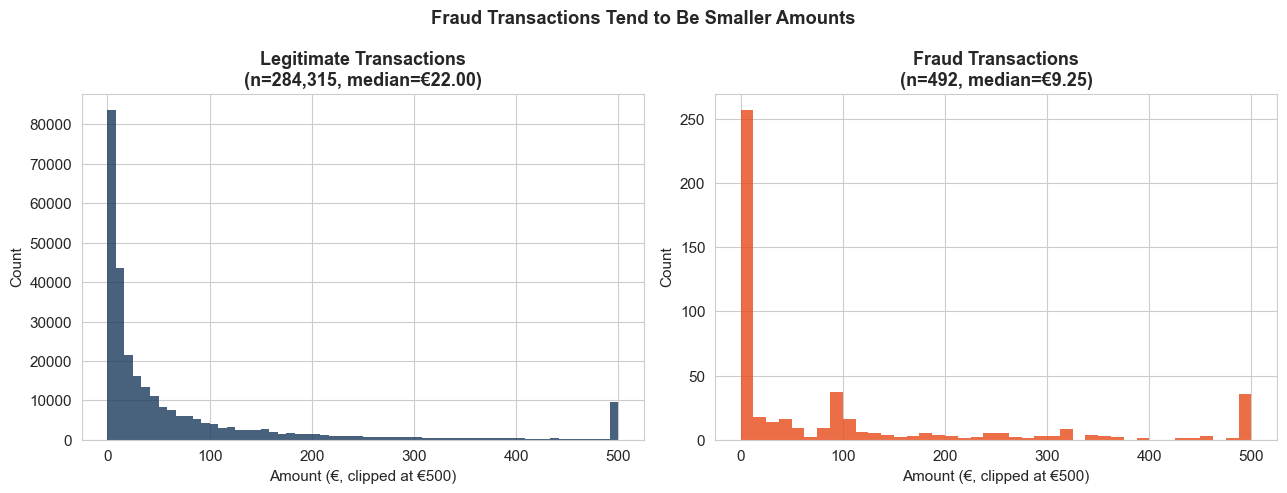

In [4]:
fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

print("=== Legitimate transactions — Amount ===")
print(legit['Amount'].describe().round(2))
print(f"\n=== Fraud transactions — Amount ===")
print(fraud['Amount'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

legit['Amount'].clip(upper=500).plot(
    kind='hist', bins=60, ax=axes[0], color=NAVY, alpha=0.8, edgecolor='none')
axes[0].set_title(f'Legitimate Transactions\n(n={len(legit):,}, median=€{legit["Amount"].median():.2f})')
axes[0].set_xlabel('Amount (€, clipped at €500)')
axes[0].set_ylabel('Count')

fraud['Amount'].clip(upper=500).plot(
    kind='hist', bins=40, ax=axes[1], color=CORAL, alpha=0.8, edgecolor='none')
axes[1].set_title(f'Fraud Transactions\n(n={len(fraud):,}, median=€{fraud["Amount"].median():.2f})')
axes[1].set_xlabel('Amount (€, clipped at €500)')
axes[1].set_ylabel('Count')

plt.suptitle('Fraud Transactions Tend to Be Smaller Amounts', fontweight='bold')
plt.tight_layout()
save('c2_amount_distribution')


## 4. Time Distribution <a id='time'></a>

Are fraud transactions clustered at certain times of day? (e.g. overnight when monitoring is lower)


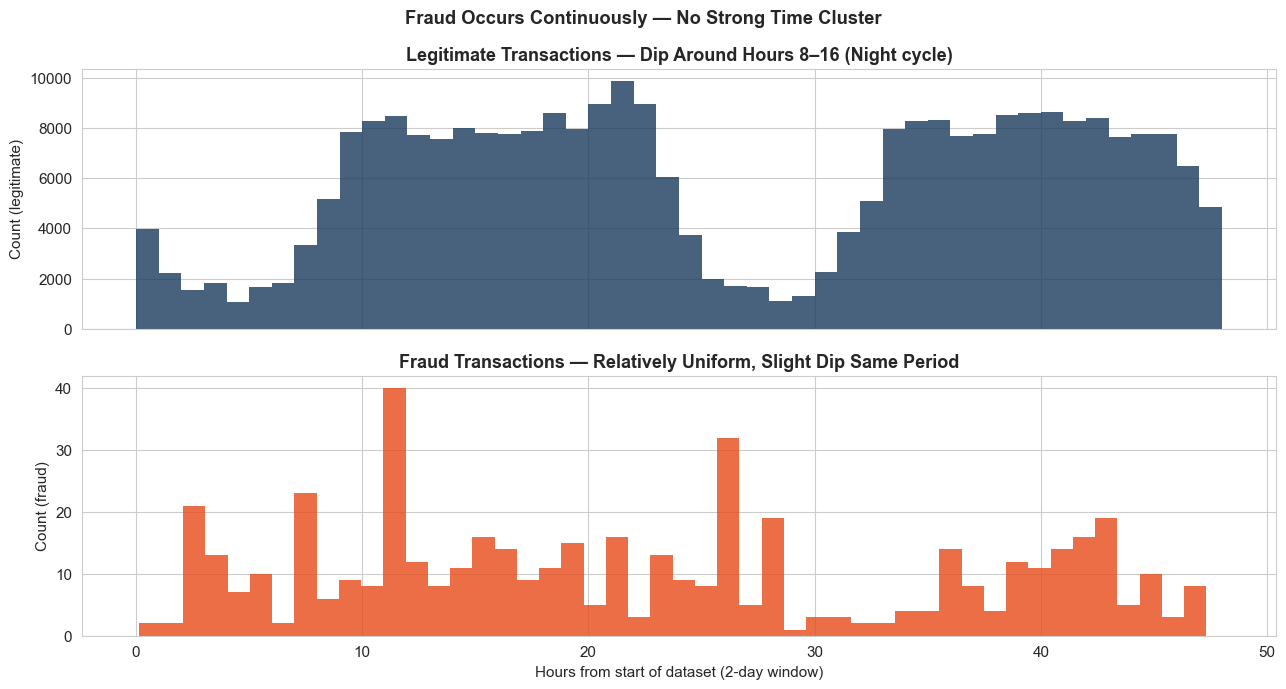

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Bin into hours
hours_legit = legit['Time'] / 3600
hours_fraud  = fraud['Time'] / 3600

axes[0].hist(hours_legit, bins=48, color=NAVY, alpha=0.8, edgecolor='none')
axes[0].set_ylabel('Count (legitimate)')
axes[0].set_title('Legitimate Transactions — Dip Around Hours 8–16 (Night cycle)')

axes[1].hist(hours_fraud, bins=48, color=CORAL, alpha=0.8, edgecolor='none')
axes[1].set_ylabel('Count (fraud)')
axes[1].set_xlabel('Hours from start of dataset (2-day window)')
axes[1].set_title('Fraud Transactions — Relatively Uniform, Slight Dip Same Period')

plt.suptitle('Fraud Occurs Continuously — No Strong Time Cluster', fontweight='bold')
plt.tight_layout()
save('c3_time_distribution')


## 5. Feature Distributions <a id='features'></a>

V1–V28 are PCA-transformed features (original features are anonymised for privacy).
We identify which features separate fraud from legitimate transactions most clearly.


In [6]:
v_cols = [f'V{i}' for i in range(1, 29)]

means_diff = abs(fraud[v_cols].mean() - legit[v_cols].mean()).sort_values(ascending=False)
print("Features ranked by mean difference (fraud vs legitimate):")
print(means_diff.round(3).to_string())

top_features = means_diff.head(6).index.tolist()
print(f"\nTop 6 most discriminative: {top_features}")


Features ranked by mean difference (fraud vs legitimate):
V3     7.045
V14    6.984
V17    6.677
V12    6.270
V10    5.687
V7     5.578
V1     4.780
V4     4.550
V16    4.147
V11    3.807
V2     3.630
V5     3.157
V9     2.586
V18    2.250
V6     1.400
V21    0.715
V19    0.682
V8     0.572
V20    0.373
V27    0.171
V13    0.110
V24    0.105
V15    0.093
V28    0.076
V26    0.052
V25    0.042
V23    0.040
V22    0.014

Top 6 most discriminative: ['V3', 'V14', 'V17', 'V12', 'V10', 'V7']


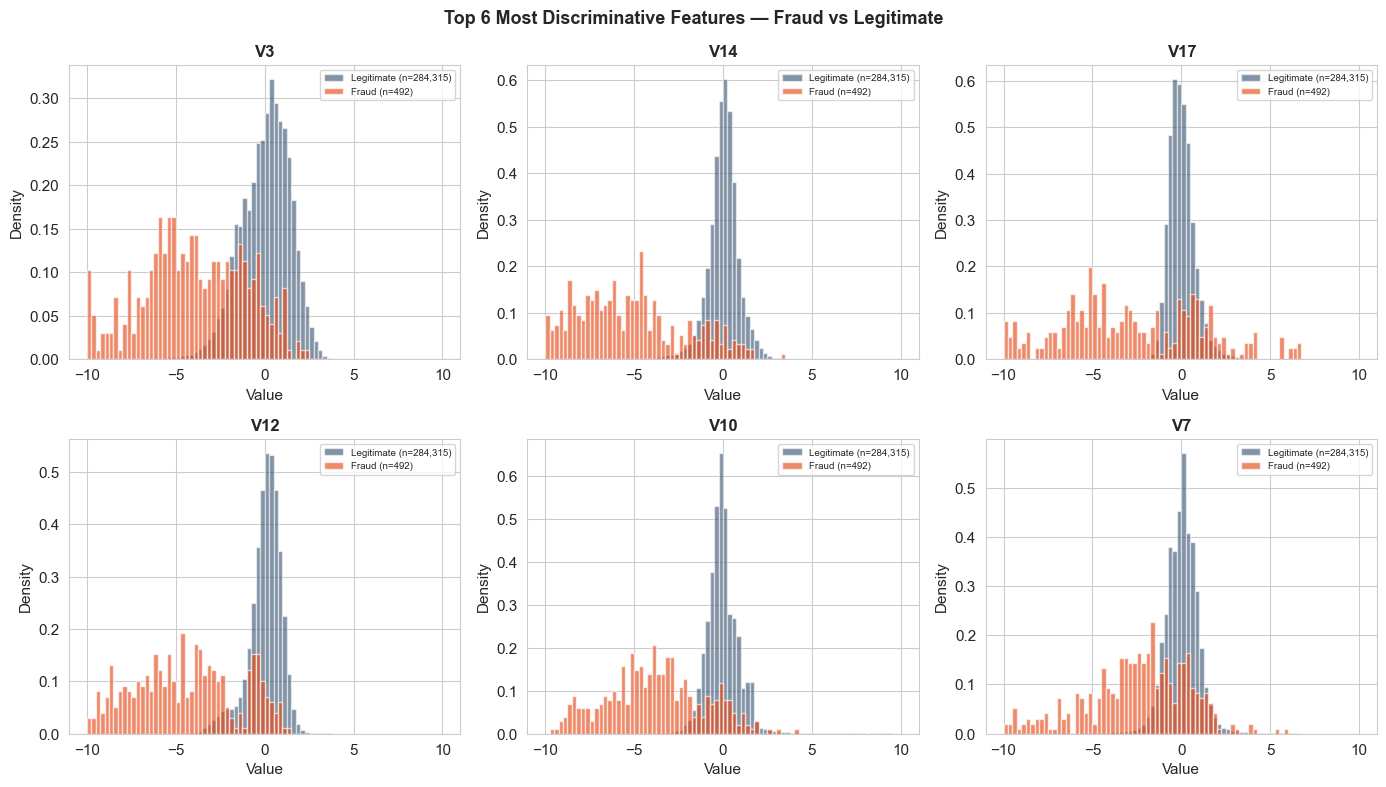

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    axes[i].hist(legit[col], bins=80, alpha=0.55, color=NAVY,
                 label=f'Legitimate (n={len(legit):,})', density=True, range=(-10, 10))
    axes[i].hist(fraud[col], bins=80, alpha=0.65, color=CORAL,
                 label=f'Fraud (n={len(fraud)})', density=True, range=(-10, 10))
    axes[i].set_title(col, fontsize=12)
    axes[i].legend(fontsize=7)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')

plt.suptitle('Top 6 Most Discriminative Features — Fraud vs Legitimate',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save('c4_feature_distributions')


## 6. Correlation Structure <a id='correlation'></a>

Because V1–V28 come from PCA, they are by construction uncorrelated with each other in the full dataset.
The correlation structure within fraud transactions alone is more informative.


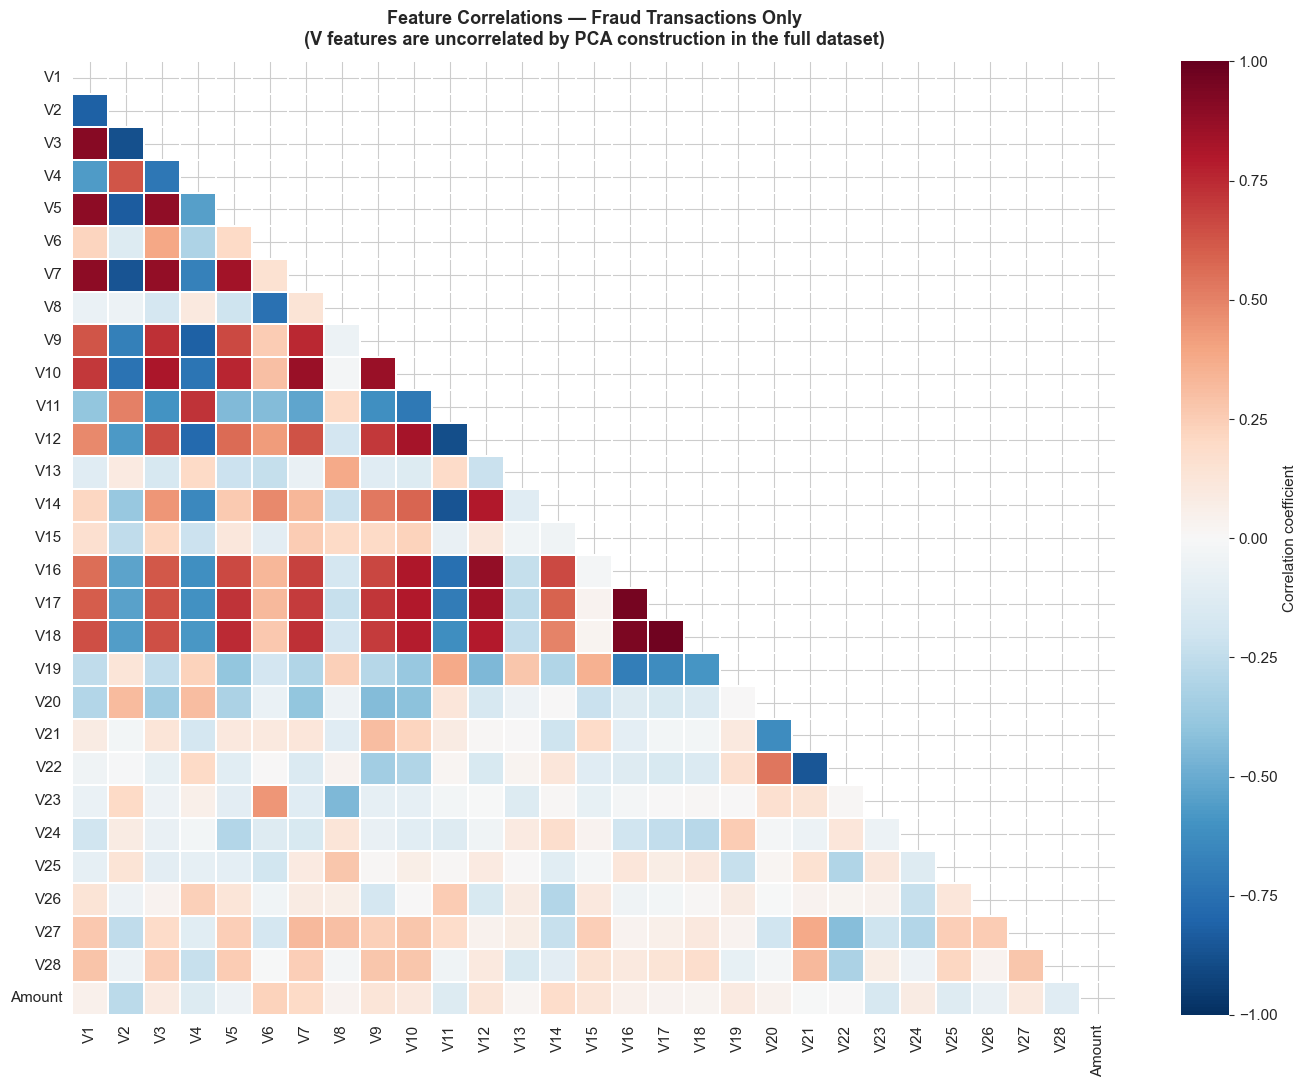

In [8]:
plt.figure(figsize=(14, 11))
corr = fraud[v_cols + ['Amount']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
            linewidths=0.3, annot=False, vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlation coefficient'})
plt.title('Feature Correlations — Fraud Transactions Only\n'
          '(V features are uncorrelated by PCA construction in the full dataset)', pad=12)
plt.tight_layout()
save('c5_fraud_correlations')


## 7. Preprocessing for Modelling <a id='preprocessing'></a>

Key decisions:
- **Scale only `Time` and `Amount`** — V1–V28 are already PCA-transformed, do not scale again
- **Stratified split** — mandatory with 0.17% positive class, otherwise split may have no fraud in test
- **SMOTE applied in notebook 02 to training set only** — never before splitting


In [9]:
scaler = StandardScaler()

df_model = df.copy()
df_model['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df_model['Time_scaled']   = scaler.fit_transform(df[['Time']])

feature_cols = v_cols + ['Amount_scaled', 'Time_scaled']
X = df_model[feature_cols].values
y = df_model['Class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows | Fraud: {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"Test set:     {X_test.shape[0]:,} rows | Fraud: {y_test.sum():,} ({y_test.mean()*100:.3f}%)")
print(f"\nStratification check: fraud rate in train ({y_train.mean():.4f}) ≈ test ({y_test.mean():.4f})")
print(f"\nFeatures used: {len(feature_cols)}")
print(f"  V features:  28 (PCA, no scaling)")
print(f"  Amount:      1  (scaled)")
print(f"  Time:        1  (scaled)")
print(f"\nData ready for notebook 02 — Modelling.")


Training set: 227,845 rows | Fraud: 394 (0.173%)
Test set:     56,962 rows | Fraud: 98 (0.172%)

Stratification check: fraud rate in train (0.0017) ≈ test (0.0017)

Features used: 30
  V features:  28 (PCA, no scaling)
  Amount:      1  (scaled)
  Time:        1  (scaled)

Data ready for notebook 02 — Modelling.
